# Optimizing FEA objectives in Simsopt
This Tutorial shows how to perform a stage-2 (coil) optimization that
simultaneously iterates the filament coil and the support clamp locations
to target the magnetic field error and von Mises stress with `coil-fem`
and `simsopt.`

## Loading the W7-X equilibrium and coils
We first load the W7-X standard configuration as the target plasma 
surface, and the W7-X coils as the initial condition.

In [1]:
from simsopt.configs import get_data
from simsopt.mhd import Vmec
import numpy as np

# Loading the W7-X standard configuration 
# plasma surface. wout file comes from Landreman's
# VMEC equilibrium archive: 
# https://github.com/landreman/vmec_equilibria/blob/master/W7-X/Standard/
eq = Vmec('data/w7x/wout.nc', keep_all_files=True)
# Adjusting resolution and taking a half-field-period
n_phi = 25
n_theta = 50
plasma_surface = type(eq.boundary)(
    nfp=eq.boundary.nfp, stellsym=eq.boundary.stellsym,
    mpol=eq.boundary.mpol, ntor=eq.boundary.ntor,
    quadpoints_phi=np.linspace(0, 1/2/eq.boundary.nfp, n_phi, endpoint=False),
    quadpoints_theta=np.linspace(0, 1, n_theta, endpoint=False),
)
plasma_surface.set_dofs(eq.boundary.get_dofs())

# Loading the W7-X coils.
coil_per_half_fp = 5
# The number of quadpoints here controls the mesh
# density in coil-fem. The meshing routine will
# try choose the cell number in the cross section 
# to make the aspect ratio close to one. Please see 
# the next sections for details. The resolution is
# low here to fit on a 8GB RTX 4060.  
curves, currents, axis, nfp, bs = get_data(
    'w7x', coil_order=10, points_per_period=4
)
base_curves = curves[:coil_per_half_fp]
base_currents = currents[:coil_per_half_fp]

## Defining `coil-fem` penalty

### Support structures
Before beginning optimization, we first define a support structure for the
coilset. Support clamps in `coil-fem` are simsopt `Optimizables`. In this
example, we use `CoilSupportFixed`, which represents support clamps suspended
in space for every base coil. In an optimization, the clamps are free to move
along each coil's centerline. Each coil has two support clamps with radius
0.3 m.


In [2]:
from simsopt.field import Coil
from coil_fem.simsopt import CoilSupportFixed

# One support object covers the whole base coilset
base_coils = [Coil(c, I) for c, I in zip(base_curves, base_currents)]
coil_support = CoilSupportFixed(
    base_coils,
    nfp=plasma_surface.nfp,
    stellsym=plasma_surface.stellsym,
    fixed_clamp_options={
        'k_clamp': 1e10,
        'r_clamp': 0.3,
        'n_clamp': 2,
    },
)


[07-08 21:16:24][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



### FEM options and material properties

In [3]:
# Rectangular 100 mm × 50 mm cross-section (half-widths in metres).
# This single dict will be broadcast to all base coils automatically.
# The mesh density is controlled by the quadpoint number in base_curve.
mesh_options = {
    'shape'       : 'rect',  # Rectangular cross sections
    'w1'          : 0.2,     # 0.20 m full-width
    'w2'          : 0.2,     # 0.20 m full-width
    'frame'       : 'rmf',   # Cross sections oriented to a rotation-minimizing frame
    'aspect_ratio': 1.0,     # Aim for cubic elements
    'mesh_type'   : 'TET10', # Quadratic tetrahedral mesh and elements.
}

# Problem and solver options.
problem_options = {
    'solver'         : 'cudss', # A GPU direct sparse solver. Strongly 
    'adjoint_solver' : 'cudss', # recommended.
}

# Material options. Here, we assumes the coils are composed
# uniformly of 316LN stainless steel. Material properties cited 
# from DOI: 10.1016/j.nucengdes.2013.08.016
material_options = {
    'E'      : 205000000000, # Young's modulus (Pa)
    'nu'     : 0.3,          # Poisson's ratio (dimless)
    'density': 8000,         # Density (kg/m³)
    'itc'    : 0.0029,       # Integral thermal contraction (ΔL/L, dimless)
}

# Gravity options.
gravity_options = {
    'g_vec': (0, 0, -9.8), # g vector in (x, y, z)   (m/s²)
}

### Defining the simsopt objective
We now defined the simsopt objective for `coil-fem`. The `CoilFEMObjective`
simsopt `Optimizable` handles all forward solves and gradient calculations.
Each `CoilFEMObjective` maintains its own FEM problem. 

The mesh density is controlled by the centerlines `quadpoints` counts. 
the number of cells in the cross section is automatically calculated to 
produce mesh cells so that each cell's aspect ratio is roughly
`mesh_options['aspect_ratio']`.

**Note:** When multiple `coil-fem` penalties are needed, please initialize one
`CoilFEMObjective` instance with a list of `metrics` and `metric_weights` 
instead of defining multiple `CoilFEMObjective` instances. This way, `coil-fem`
can compute all metrics and gradients in one FEM pass. Creating multiple 
`CoilFEMObjective` instances for the same problem will cause `coil-fem` to repeat 
the same FEM computation. This will cause unnecessary memory and time usage. 


The mesh node counts for the coils are: [720, 720, 720, 720, 720]
The mesh cell counts for the coils are: [240, 240, 240, 240, 240]


<Axes3D: xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

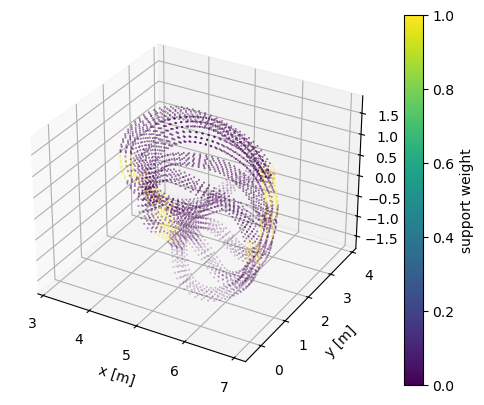

In [4]:
from coil_fem.simsopt import CoilFEMObjective

# The Simsopt wrapper for a differentiable FEM problem.
# It behaves like a simsopt objective.
Jstress = CoilFEMObjective(
    coil_support,
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    mesh_options     = mesh_options,
    material_options = material_options,
    gravity_options  = gravity_options,
    problem_options  = problem_options,
)
print('# mesh node for all coils:', Jstress.n_nodes)
print('# mesh cell for all coils:', Jstress.n_cells)
# Viusualizing the mesh nodes and support clamps before optimization
Jstress.plot_support()


## Defining other penalties
We now populate the rest of the objective with standard 
stage-2 optimization penalties, such as field error, 
lengths and curvature.

In [5]:
# Importing necessary simsopt components
from simsopt.objectives import SquaredFlux
from simsopt.objectives.utilities import QuadraticPenalty
from simsopt.field import coils_via_symmetries
from simsopt.geo import (
    CurveSurfaceDistance, CurveCurveDistance, 
    LpCurveCurvature, CurveLength, LinkingNumber
)

# Defining target values 
CC_TARGET = 0.29 # Coil-coil distance target (m)
CP_TARGET = 0.40 # Coil-plasma distance target (m)
CURVATURE_TARGET = 2.56 # Curvature target (1/m)

1. Field error term `Jf_norm_cons`

In [6]:
# Defining a field-error term based on the 
# normalized squared-flux of the baseline W7-X coils
Jf_norm = SquaredFlux(
    plasma_surface, bs,
    definition='normalized',
)
FLUX_NORM_TARGET = Jf_norm.J()
Jf_norm_cons = QuadraticPenalty(Jf_norm, FLUX_NORM_TARGET, 'max')

2. Curve-curve distance penalty `Jccdist`

In [7]:
# base_curves only contains a half-period. 
# curve-curve distance need to use the full 
# set of curves produced by coils_via_symmetries
coils = coils_via_symmetries(
    base_curves, base_currents, 
    plasma_surface.nfp, True
)
curves_for_ccd = [c.curve for c in coils]

# Defining Jccdist
Jccdist = CurveCurveDistance(
    curves_for_ccd, CC_TARGET
) * (1 / CC_TARGET)

3. Coil-surface distance penalty `Jcsdist`

In [8]:
Jcsdist = CurveSurfaceDistance(
    base_curves, plasma_surface, CP_TARGET
) * (1 / plasma_surface.minor_radius())

4. Curvature penalties `Jcs`

In [9]:
Jcs = [
    LpCurveCurvature(c, p=2, threshold=CURVATURE_TARGET)
    * plasma_surface.minor_radius()**2
    for c in base_curves
]

5. Length penalties `Jls`

In [10]:
Jls = [
    QuadraticPenalty(CurveLength(c), CurveLength(c).J(), "max", ) 
    for c in base_curves
]

6. Linking number `linkNum`

In [11]:
linkNum = LinkingNumber(curves_for_ccd)

## Defining the objective function and optimize
We perform a standard stage-2 optimization with penalty method and empirical weight factors.

In [12]:
# Some empirical weight factors. These factors
# are chosen based on the unit and typical 
# orders of magnitude of each penalty.
FLUX_WEIGHT = 500000
CC_WEIGHT = 100
CS_WEIGHT = 100
CURVATURE_WEIGHT = 1000
LENGTH_WEIGHT = 200
LINK_WEIGHT = 10
STRESS_WEIGHT = 1e-18

JF = (
    FLUX_WEIGHT ** 2 * Jf_norm_cons
    + CC_WEIGHT * Jccdist
    + CS_WEIGHT * Jcsdist
    + CURVATURE_WEIGHT * sum(Jcs)
    + LENGTH_WEIGHT * sum(Jls)
    + LINK_WEIGHT * linkNum
    + STRESS_WEIGHT * Jstress
)

# Storing the initial state for comparison
dofs_init = JF.x.copy()

# Define callable for scipy.minimize
def fun(dofs):
    JF.x = dofs
    J = JF.J()
    grad = JF.dJ()
    return J, grad

# Track convergence
def callback(dofs):
    print('J =', JF.J())

In [13]:
from scipy.optimize import minimize

# Run optimization
res = minimize(
    fun, dofs_init, jac=True, method='L-BFGS-B',
    options={
        'maxiter': 10,
        'maxcor': 300,
        'maxfun': 100,
        'maxls': 60,
    },
    tol=1e-5,
    callback=callback,
)

solving with float64
solving with float64
J = 0.11549254739674444
J = 0.11412013484160798
J = 0.1138126731822113
J = 0.11321930652909892
J = 0.1121558686305801
J = 0.11201940019316374
J = 0.10951422587125349
J = 0.10750278236635817
J = 0.10633606763522979
J = 0.10527424784301598


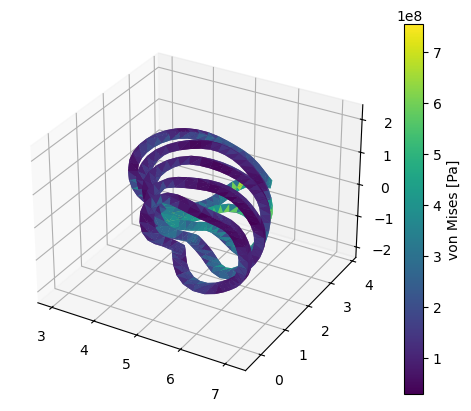

After optimization


In [14]:
JF.x = res.x
# Perform a forward solve and plot von Mises
Jstress.plot_support()
print('After optimization')

## Saving and visualization
Results from a `coil-fem` optimization can be saved in two formats.

### Simsopt json
Objects in `coil_fem.simsopt` are fully compatible with `simsopt` serialization. 
Serializing a `CoilFEMObjective` instance method saves the support and coil
configurations, but not the FEM results. 

**Note:** A lone, loaded `CoilFEMObjective` includes the coil support via
`CoilFEMObjective._coil_support`, which exposes:
```
CoilFEMObjective._coil_support.base_curves
CoilFEMObjective._coil_support.base_currents
CoilFEMObjective._coil_support.support_dofs
```
Be careful which coils/support you use when restarting an optimization with a
`CoilFEMObjective`.


In [15]:
from simsopt import save, load
from simsopt.geo import plot
import os
os.makedirs('tutorial_out', exist_ok=True)
save([Jstress], 'tutorial_out/optimized_Jstress.json')

In [16]:
Jstress_recovered = load('tutorial_out/optimized_Jstress.json')[0]

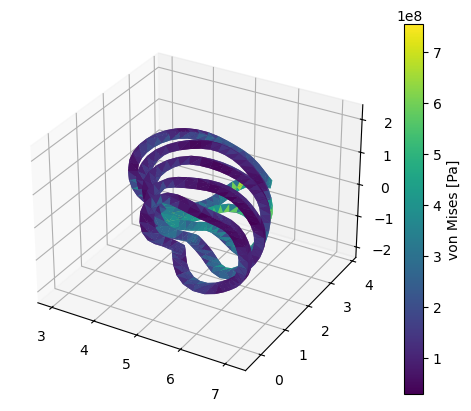

<Axes3D: >

In [20]:
# Perform a forward solve and plot von Mises
Jstress_recovered.plot()

### Paraview
The support geometry and FEM results can be both be saved 
as paraview files by `save_support_vtu` and `save_run_vtu`.
The latter will force a fresh forward solve and is slower. 

In [18]:
list_of_names = Jstress.save_support_vtu('tutorial_out/optimized_vtu')
print('Support geometry saved at:\n'+'\n'.join(list_of_names))
list_of_names = Jstress.save_run_vtu('tutorial_out/optimized_vtu')
print('FEM results saved at:\n'+'\n'.join(list_of_names))

Support geometry saved at:
tutorial_out/optimized_vtu/coil00_support.vtu
tutorial_out/optimized_vtu/coil01_support.vtu
tutorial_out/optimized_vtu/coil02_support.vtu
tutorial_out/optimized_vtu/coil03_support.vtu
tutorial_out/optimized_vtu/coil04_support.vtu
FEM results saved at:
tutorial_out/optimized_vtu/coil00_run.vtu
tutorial_out/optimized_vtu/coil01_run.vtu
tutorial_out/optimized_vtu/coil02_run.vtu
tutorial_out/optimized_vtu/coil03_run.vtu
tutorial_out/optimized_vtu/coil04_run.vtu
